In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 
import TCR_embedings

AttributeError: module 'numba' has no attribute 'core'

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

In [ ]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "T_DE5000_singleVDJ_emb.h5mu"
DATA_PATH = path + filename

mdata = mu.read(DATA_PATH)

In [ ]:
## select one cell from each clonotype

airr_obs = mdata['airr'].obs.copy()
clone_id_col = airr_obs['clone_id']
if hasattr(clone_id_col, 'cat'):
    clone_id_col = clone_id_col.astype(str)
airr_obs['_clone_id_str'] = clone_id_col

expanded = airr_obs[airr_obs['clone_id_size'] > 1].dropna(subset=['_clone_id_str'])
sampled_expanded_idx = (
    expanded
    .groupby('_clone_id_str', observed=True)
    .sample(n=1, random_state=42)
    .index
)

single_idx = airr_obs[airr_obs['clone_id_size'] == 1].index
keep_idx = sampled_expanded_idx.append(single_idx)

mdata = mdata[keep_idx].copy()
print(f"Expanded clones: {len(expanded)} cells -> {len(sampled_expanded_idx)} (1 per clone)")
print(f"Single clones: {len(single_idx)}")
print(f"Total after dedup: {mdata.n_obs} cells")

mdata = mdata[~mdata.obs['source'].isin(['Blood'])]
mdata.obs['source'].value_counts()

Expanded clones: 11391 cells -> 1361 (1 per clone)
Single clones: 3566
Total after dedup: 4927 cells


source
Tumor    2410
NAT      2192
Blood       0
Name: count, dtype: int64

In [ ]:
gex = mdata['gex']
tcr_embs = mdata.obsm['tcr_embs']

In [ ]:
## loading high TCR-gex corr subset  ##
import os
outdir = 'Tumor_s_vs_multi'
corr_df_sig = pd.read_csv(os.path.join(outdir, 'gene_tcr_corr_sig_fdr05.csv'))

topK_setting = 20

subtype_total = corr_df_sig['subtype'].nunique()
pair_common = (
      corr_df_sig.groupby(['gene', 'tcr_col_idx'], as_index=False)
      .agg(
      tcr_col=('tcr_col', 'first'),
      subtype_count=('subtype', 'nunique'),
      row_count=('gene', 'size'),
      )
      .sort_values(
      ['subtype_count', 'row_count', 'gene', 'tcr_col_idx'],
      ascending=[False, False, True, True],
      )
)
# Pairs significant in at least 2 subtypes; top 10 by subtype_count
top10_common_pairs = pair_common[pair_common['subtype_count'] >= 2].head(topK_setting)
print(f"Total subtypes represented in corr_df_sig: {subtype_total}")

if top10_common_pairs.empty:
    print('No common (gene, tcr_col) pairs across multiple subtypes in corr_df_sig.')
else:
    top10_common_pairs

Total subtypes represented in corr_df_sig: 5


In [ ]:
pair_common_subtype = pair_common[pair_common['subtype_count'] > 2]
pair_common_subtype

,gene,tcr_col_idx,tcr_col,subtype_count,row_count
2106,FGFBP2,141,X_VJ_1_cdr3_aa_atchley_19,5,5
263,CCL4L1,159,X_VJ_1_cdr3_aa_atchley_37,4,4
465,CD69,57,X_VDJ_1_cdr3_aa_atchley_55,4,4
1306,DNAJB1,19,X_VDJ_1_cdr3_aa_atchley_17,4,4
1308,DNAJB1,21,X_VDJ_1_cdr3_aa_atchley_19,4,4
...,...,...,...,...,...
4131,PLEK,161,X_VJ_1_cdr3_aa_atchley_39,3,3
4144,PLEK,227,X_VJ_1_cdr3_aa_composition_5,3,3
4147,PLEK,232,X_VJ_1_cdr3_aa_composition_10,3,3
4153,PLEK,242,VDJ_1_cdr3_aa_length,3,3


In [ ]:
### Deep CCA: data prep from pair_common_subtype ###
genes = pair_common_subtype['gene'].unique().tolist()
tcr_idxs = pair_common_subtype['tcr_col_idx'].unique().tolist()

#### subset with pair_common_subtype  ###
# view_gene: expression matrix for selected genes
gene_mask = [g in gex.var_names for g in genes]
genes_valid = [g for g, ok in zip(genes, gene_mask) if ok]

view_gene = gex[:, genes_valid].X
if issparse(view_gene):
    view_gene = view_gene.toarray()
view_gene = np.asarray(view_gene, dtype=float)

# view_tcr: selected TCR embedding columns
view_tcr = np.asarray(tcr_embs[:, tcr_idxs], dtype=float)


In [ ]:
#### no subsetteing  ####
view_gene = gex.X.toarray()
# view_gene = np.asarray(view_gene, dtype=float)
view_tcr = np.asarray(tcr_embs, dtype=float)


In [ ]:
scaler = StandardScaler()
view_gene = scaler.fit_transform(view_gene)
view_tcr = scaler.fit_transform(view_tcr)

print(f"view_gene: {view_gene.shape}  ({len(genes_valid)} genes)")
print(f"view_tcr:  {view_tcr.shape}  ({len(tcr_idxs)} TCR dims)")

view_gene: (4602, 2500)  (21 genes)
view_tcr:  (4602, 244)  (104 TCR dims)


## CCA

In [ ]:
mdata.obs['set'].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
### Train / test split + dataloaders ###
from sklearn.model_selection import train_test_split

train_frac = 0.8
dim_cca = min(view_gene.shape[1], view_tcr.shape[1], 5)

train_mask = np.random.rand(mdata.n_obs) < train_frac
test_mask = ~train_mask
mdata.obs.loc[train_mask, 'set'] = 'train'
mdata.obs.loc[test_mask, 'set'] = 'test'


view_gene_train = view_gene[train_mask]
view_gene_test = view_gene[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(f"Train: {view_gene_train.shape[0]}  Test: {view_gene_test.shape[0]}")
print(f"Latent dims (dim_cca): {dim_cca}")

Train: 3697  Test: 905
Latent dims (dim_cca): 5


In [ ]:
### Deep CCA: fit ###
from cca_zoo.deep import DCCA, architectures
from cca_zoo.deep.data import NumpyDataset, check_dataset, get_dataloaders
import lightning.pytorch as pl

LATENT_DIMS = dim_cca
EPOCHS = 30
BATCH_SIZE = 64

train_dataset = NumpyDataset([view_gene_train, view_tcr_train])
test_dataset = NumpyDataset([view_gene_test, view_tcr_test])

train_loader = get_dataloaders(train_dataset, batch_size=BATCH_SIZE)
test_loader = get_dataloaders(test_dataset, batch_size=BATCH_SIZE)

encoder_1 = architectures.Encoder(
    latent_dimensions=LATENT_DIMS, feature_size=view_gene_train.shape[1],
)
encoder_2 = architectures.Encoder(
    latent_dimensions=LATENT_DIMS, feature_size=view_tcr_train.shape[1],
)

dcca = DCCA(latent_dimensions=LATENT_DIMS, encoders=[encoder_1, encoder_2])
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    enable_checkpointing=True,
    enable_model_summary=True,
    enable_progress_bar=True,
)
trainer.fit(dcca, train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type       | Params | Mode  | FLOPs
--------------------------------------------------------
0 | encoders | ModuleList | 352 K  | train | 0    
--------------------------------------------------------
352 K     Trainable params
0         Non-trainable params
352 K     Total params
1.411     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
0         Total Flops


Epoch 29: 100%|██████████| 57/57 [00:00<00:00, 88.47it/s, v_num=6]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 57/57 [00:00<00:00, 83.41it/s, v_num=6]


In [ ]:
### Deep CCA: transform + evaluate ###
# Rebuild loaders without dropping the last batch so all samples are included
from torch.utils.data import DataLoader
train_loader_full = DataLoader(NumpyDataset([view_gene_train, view_tcr_train]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)
test_loader_full = DataLoader(NumpyDataset([view_gene_test, view_tcr_test]), batch_size=BATCH_SIZE, drop_last=False, shuffle=False)

view_gene_c_train, view_tcr_c_train = dcca.transform(train_loader_full)
view_gene_c_test, view_tcr_c_test = dcca.transform(test_loader_full)

# Standardise canonical variates
view_gene_c_train = scaler.fit_transform(view_gene_c_train)
view_tcr_c_train = scaler.fit_transform(view_tcr_c_train)
view_gene_c_test = scaler.fit_transform(view_gene_c_test)
view_tcr_c_test = scaler.fit_transform(view_tcr_c_test)

# Combine into full-dataset arrays
view_gene_c = np.zeros((mdata.n_obs, LATENT_DIMS))
view_tcr_c = np.zeros((mdata.n_obs, LATENT_DIMS))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test

# Store canonical variate scores in mdata
for i in range(LATENT_DIMS):
    mdata['gex'].obs[f'DCCA_CV_{i}'] = view_tcr_c[:, i]

# Per-component correlations
print("Per-component correlations (train / test):")
for i in range(LATENT_DIMS):
    r_tr = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
    r_te = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
    print(f"  CC {i}: train {r_tr:.4f}  test {r_te:.4f}")

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape:  {view_gene_c_test.shape}")

Per-component correlations (train / test):
  CC 0: train -0.0352  test -0.0106
  CC 1: train 0.0353  test -0.0161
  CC 2: train -0.0247  test 0.0238
  CC 3: train -0.0182  test -0.0517
  CC 4: train -0.0049  test 0.0291

Train canonical variates shape: (3697, 5)
Test canonical variates shape:  (905, 5)


<Figure size 600x600 with 0 Axes>

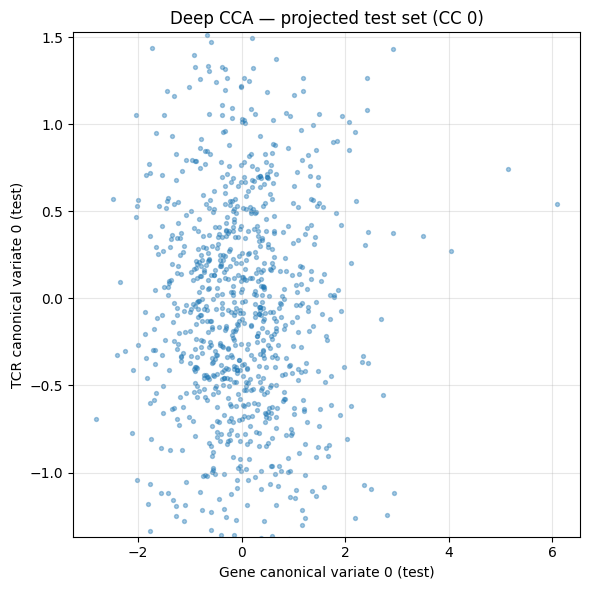

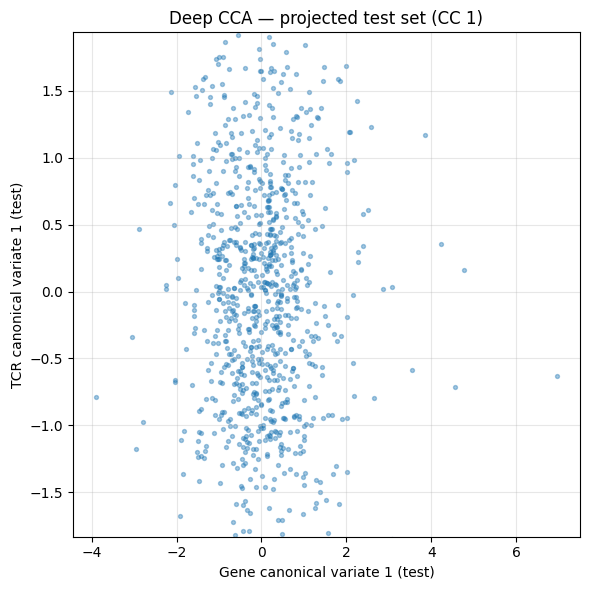

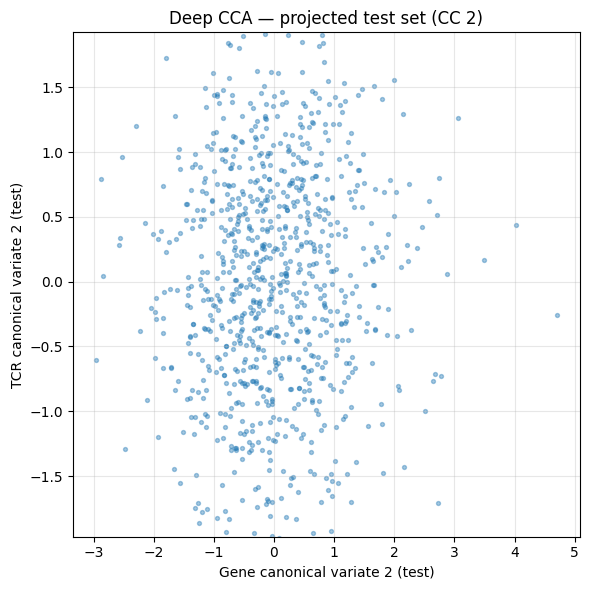

In [ ]:
### Scatter: gene vs TCR canonical variates (test set) ###
plt.figure(figsize=(6, 6))
for i in range(min(LATENT_DIMS, 3)):
    plt.figure(figsize=(6, 6))
    plt.scatter(
        view_gene_c_test[:, i], view_tcr_c_test[:, i],
        alpha=0.4, s=8,
    )
    plt.xlabel(f'Gene canonical variate {i} (test)')
    plt.ylabel(f'TCR canonical variate {i} (test)')
    y_95 = np.percentile(view_tcr_c_test[:, i], [2.5, 97.5])
    plt.ylim(y_95)
    plt.title(f'Deep CCA — projected test set (CC {i})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
corr_train, corr_test = TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      -0.0352         -0.0106         -0.0246        
Component 2      0.0353          -0.0161         0.0514         
Component 3      -0.0247         0.0238          -0.0485        
Component 4      -0.0182         -0.0517         0.0335         
Component 5      -0.0049         0.0291          -0.0340        


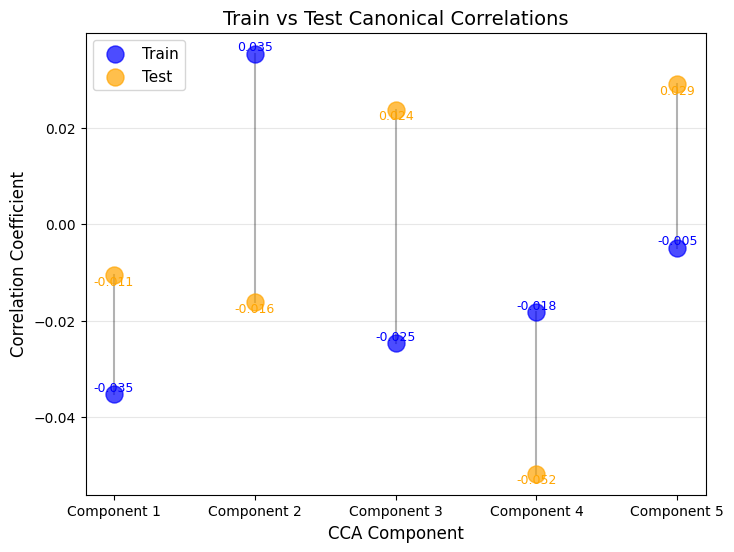

In [ ]:
ax = TCR_embedings.plot_train_test_corr(corr_train, corr_test)
# ax.set_ylim(0, 1)

## logit regression

In [ ]:
aa

In [ ]:
### Logistic Regression per subtype: predict clone_status using DCCA canonical variates ###
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
import torch
import torch.nn as nn

tg = target_groups if 'target_groups' in globals() else [
    'Tumor_multiSite_clone',
    'Tumor_singleSite_clone',
]
g1, g2 = tg[0], tg[1]

cs = mdata.obs['clone_status'].astype(str).to_numpy()
sub = mdata.obs['subtype'].astype(str).to_numpy()
in_groups = np.isin(cs, tg)

y_all = (cs == g1).astype(int)

subtypes = sorted(set(sub[in_groups]))

class WeightedLogistic(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.ones(n_features))
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x * self.feature_weights).squeeze(-1)

lr_results = []

for st in subtypes:
    st_mask = sub == st
    mask_tr = train_mask & in_groups & st_mask
    mask_te = test_mask & in_groups & st_mask

    X_tr = view_tcr_c[mask_tr]
    X_te = view_tcr_c[mask_te]
    y_tr = y_all[mask_tr]
    y_te = y_all[mask_te]

    if X_tr.shape[0] < 10 or X_te.shape[0] < 4:
        continue
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        continue

    ros = RandomOverSampler(random_state=42)
    X_tr_bal, y_tr_bal = ros.fit_resample(X_tr, y_tr)

    # Trainable-weight logistic
    wlr_epochs = 200
    X_tr_t = torch.tensor(X_tr_bal, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_bal, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    wlr = WeightedLogistic(X_tr_t.shape[1])
    optimizer = torch.optim.Adam(wlr.parameters(), lr=1e-2)
    loss_fn = nn.BCEWithLogitsLoss()

    wlr.train()
    for epoch in range(wlr_epochs):
        optimizer.zero_grad()
        loss_fn(wlr(X_tr_t), y_tr_t).backward()
        optimizer.step()

    wlr.eval()
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(wlr(X_te_t)).numpy()
        y_pred = (y_pred_proba >= 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    try:
        auc = roc_auc_score(y_te, y_pred_proba)
    except ValueError:
        auc = np.nan

    learned_w = wlr.feature_weights.detach().numpy()

    lr_results.append({
        'subtype': st,
        'n_train': X_tr_bal.shape[0],
        'n_test': X_te.shape[0],
        'accuracy': acc,
        'roc_auc': auc,
        'feature_weights': learned_w.tolist(),
    })

    print(f"\n{'='*60}")
    print(f"Subtype: {st}  (train={X_tr_bal.shape[0]}, test={X_te.shape[0]})")
    print(f"{'='*60}")
    print(f"Feature weights: {learned_w}")
    print(f"Accuracy: {acc:.4f}   ROC AUC: {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=[g2, g1], zero_division=0))

lr_results_df = pd.DataFrame(lr_results)
lr_results_df



Subtype: CD8_Teff  (train=88, test=15)
Feature weights: [1.2161783  0.9669336  0.69891906 1.015396   1.0360068 ]
Accuracy: 0.5333   ROC AUC: 0.6250
                        precision    recall  f1-score   support

Tumor_singleSite_clone       0.60      0.38      0.46         8
 Tumor_multiSite_clone       0.50      0.71      0.59         7

              accuracy                           0.53        15
             macro avg       0.55      0.54      0.52        15
          weighted avg       0.55      0.53      0.52        15


Subtype: CD8_Tem  (train=216, test=49)
Feature weights: [0.8934357  1.3472291  0.85385764 1.0562571  1.0192412 ]
Accuracy: 0.5306   ROC AUC: 0.5882
                        precision    recall  f1-score   support

Tumor_singleSite_clone       0.68      0.62      0.65        34
 Tumor_multiSite_clone       0.28      0.33      0.30        15

              accuracy                           0.53        49
             macro avg       0.48      0.48      0.47    

,subtype,n_train,n_test,accuracy,roc_auc,feature_weights
0,CD8_Teff,88,15,0.533333,0.625000,"[1.216178297996521, 0.9669336080551147, 0.6989..."
1,CD8_Tem,216,49,0.530612,0.588235,"[0.8934357166290283, 1.3472291231155396, 0.853..."
2,CD8_Trm_exh_H,170,25,0.680000,0.600000,"[1.1235884428024292, 0.900972843170166, 0.9890..."
3,CD8_Trm_exh_L,110,22,0.500000,0.458333,"[1.0510834455490112, 0.7695766091346741, 1.090..."
4,CD8_Trm_exh_M,94,21,0.476190,0.411111,"[1.3072103261947632, 0.9890508055686951, 1.288..."
